In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Step 1: Generate synthetic data
np.random.seed(42)
n_samples = 3000
n_features = 8

X = np.random.rand(n_samples, n_features)
true_coefficients = np.random.rand(n_features)
y = X @ true_coefficients + np.random.normal(scale=0.5, size=n_samples)

In [2]:
# Step 2: Compute 5-fold CV for 10 cycles
n_fold = 5
n_repeats = 10
avg_mae = []

for n_cycle in range(n_repeats):
    # New CV for each cycle
    mae_list = []
    cv = KFold(n_splits=n_fold, shuffle=True, random_state=n_cycle)

    for train_index, test_index in cv.split(X):
        # Split training set and test set for current fold
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Train linear regression model on current fold
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Prediction and testing on current fold
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mae_list.append(mae)

    # Average MAE for the current cycle
    cycle_mae = np.mean(mae_list)
    avg_mae.append(cycle_mae)
    print(f"Cycle {n_cycle + 1} MAE: {cycle_mae:.4f}")

Cycle 1 MAE: 0.3990
Cycle 2 MAE: 0.3983
Cycle 3 MAE: 0.3983
Cycle 4 MAE: 0.3981
Cycle 5 MAE: 0.3986
Cycle 6 MAE: 0.3994
Cycle 7 MAE: 0.3994
Cycle 8 MAE: 0.3988
Cycle 9 MAE: 0.3988
Cycle 10 MAE: 0.3988


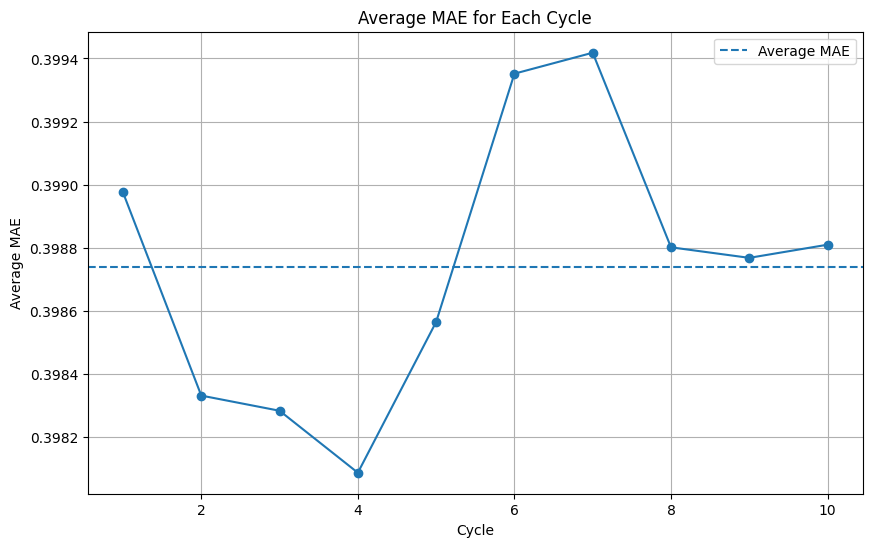

In [3]:
# Step 3: Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_repeats + 1), avg_mae, marker='o', linestyle='-')
plt.axhline(y=np.mean(avg_mae), linestyle='--', label='Average MAE')
plt.legend()
plt.title('Average MAE for Each Cycle')
plt.xlabel('Cycle')
plt.ylabel('Average MAE')
plt.grid(True)
plt.show()